In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")

In [3]:
using ColorSchemes

In [4]:
using ColorSchemes

In [5]:
using GLMakie
using CairoMakie
CairoMakie.activate!()
using Statistics

Load data
This reduced data has everything except the full state at every time point (so no space-time diagrams here)# Load data
This reduced data has everything except the full state at every time point (so no space-time diagrams here)

# Load data

In [7]:
setup_df = load("systems.jld2", "pde_df")   # params, Ds, u0 - join on pde_df_row
odes_df = load("test1.jld2", "df")   # the ode solutions
df = load("run_stats.jld2", "df")
smd = load("systems.jld2", "metadata")
T = setup_df.T[1]

Ns = Nr = 20

df1 = df[df.run .== "data",Not(:run)]
df2 = df[df.run .== "st4",Not(:run)]
@show nrow(df1), nrow(df2)

heavy = [:final_state, :saved_ts, :biomass_t]
first(select(df, Not(heavy)), 6)

(nrow(df1), nrow(df2)) = (60, 60)

Row,run,pde_df_row,gdf_row,df_row,p,L,sN,T,retcode,final_T,maxresid,num_saved,realtime
,String,Int64,Int64,Int64,Float64,Float64,Int64,Float64,T,Float64,Float64,Int64,Float64
1,data,1,1,10,1.0,40.5011,1000,1.0e8,Success,1.0e8,9.39688e-8,348,7411.12
2,data,2,1,10,0.1,40.5011,1000,1.0e8,Success,1.0e8,1.36819e-8,598,8677.53
3,data,3,2,97,1.0,42.1673,1000,1.0e8,Success,1.0e8,3.19538e-9,328,7627.2
4,data,4,2,97,0.1,42.1673,1000,1.0e8,Success,1.0e8,4.89386e-13,63,516.978
5,data,5,3,79,1.0,44.2575,1000,1.0e8,Success,1.0e8,2.46566e-8,337,7721.0
6,data,6,3,79,0.1,44.2575,1000,1.0e8,Success,1.0e8,4.12115e-13,62,514.437


# final_T distribution

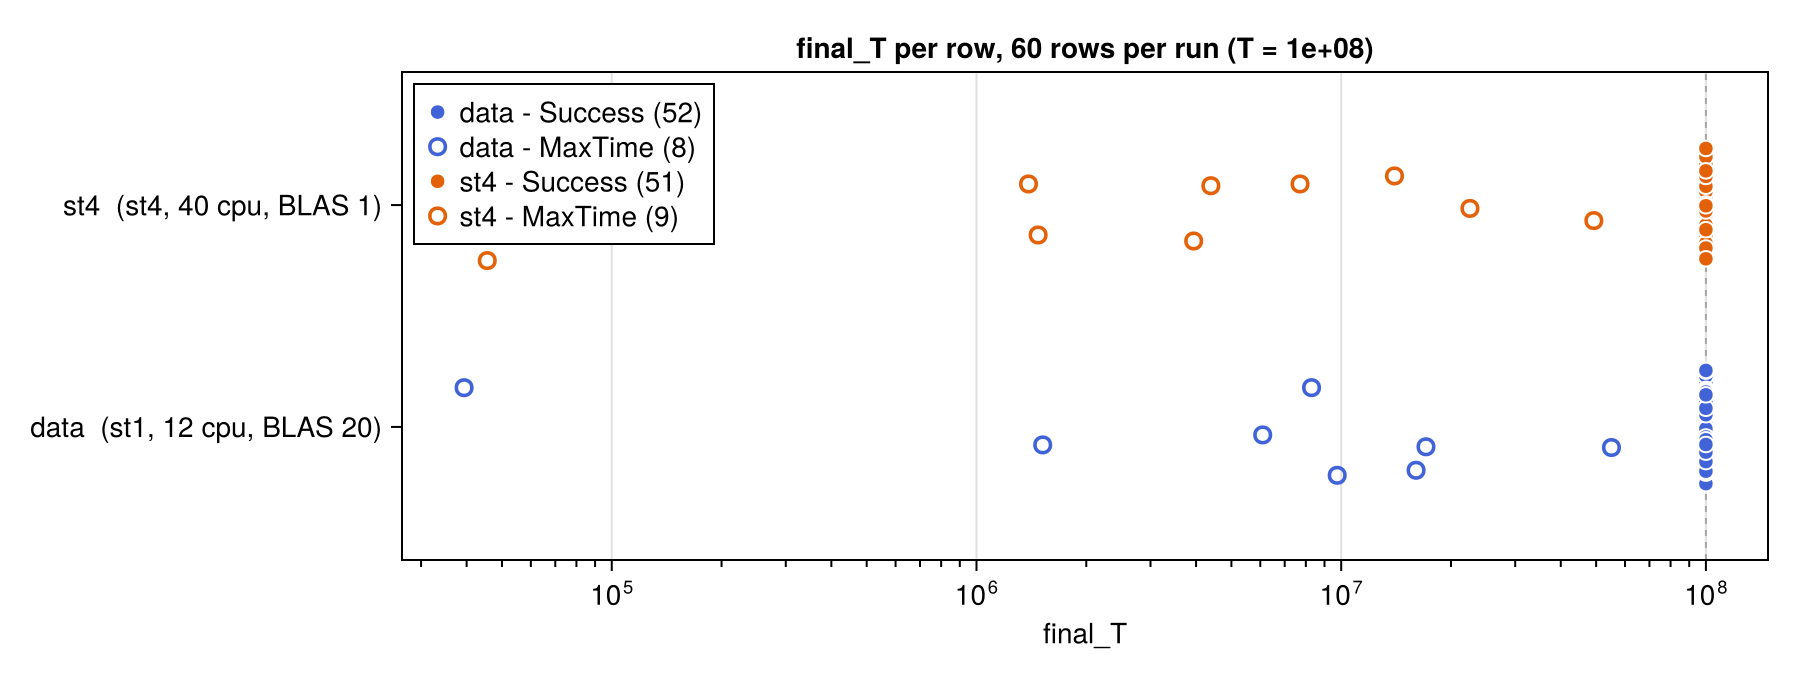

In [9]:
using Random

order = ["data", "st4"]
labels = Dict("data" => "data  (st1, 12 cpu, BLAS 20)", "st4" => "st4  (st4, 40 cpu, BLAS 1)")
colors = Dict("data" => "#4063D8", "st4" => "#E36209")  # CVD separation dE 29 at worst

fig = Figure(; size=(900, 340))
ax = Axis(fig[1, 1];
    xscale=log10, xlabel="final_T", ylabel="",
    title=@sprintf("final_T per row, %d rows per run (T = %.3g)", length(unique(df.pde_df_row)), T),
    yticks=(1:length(order), [labels[k] for k in order]),
    xminorticksvisible=true, xminorticks=IntervalsBetween(9),
    ygridvisible=false,
)

vlines!(ax, T; color=:grey65, linestyle=:dash, linewidth=1)  # where every Success row sits

Random.seed!(1)  # so the jitter redraws the same each time
for (j, k) in enumerate(order)
    g = df[df.run.==k, :]
    ok = g.retcode .== ReturnCode.Success
    ys = j .+ 0.26 .* (2 .* rand(nrow(g)) .- 1)  # jitter, the y axis carries no data
    # retcode goes on fill rather than colour, so it survives greyscale
    scatter!(ax, g.final_T[ok], ys[ok];
        color=colors[k], markersize=11, strokewidth=1, strokecolor=:white,
        label=@sprintf("%s - Success (%d)", k, count(ok)))
    scatter!(ax, g.final_T[.!ok], ys[.!ok];
        color=(:white, 0.0), markersize=11, strokewidth=1.8, strokecolor=colors[k],
        label=@sprintf("%s - MaxTime (%d)", k, count(.!ok)))
end

ylims!(ax, 0.4, length(order) + 0.6)
axislegend(ax; position=:lt, framevisible=true, patchsize=(12, 12), rowgap=1)

CairoMakie.save("final_T_distribution.pdf", fig)  # save is ambiguous unqualified
fig

Total  as a function of t# Total biomass as a function of t

# Total biomass in time

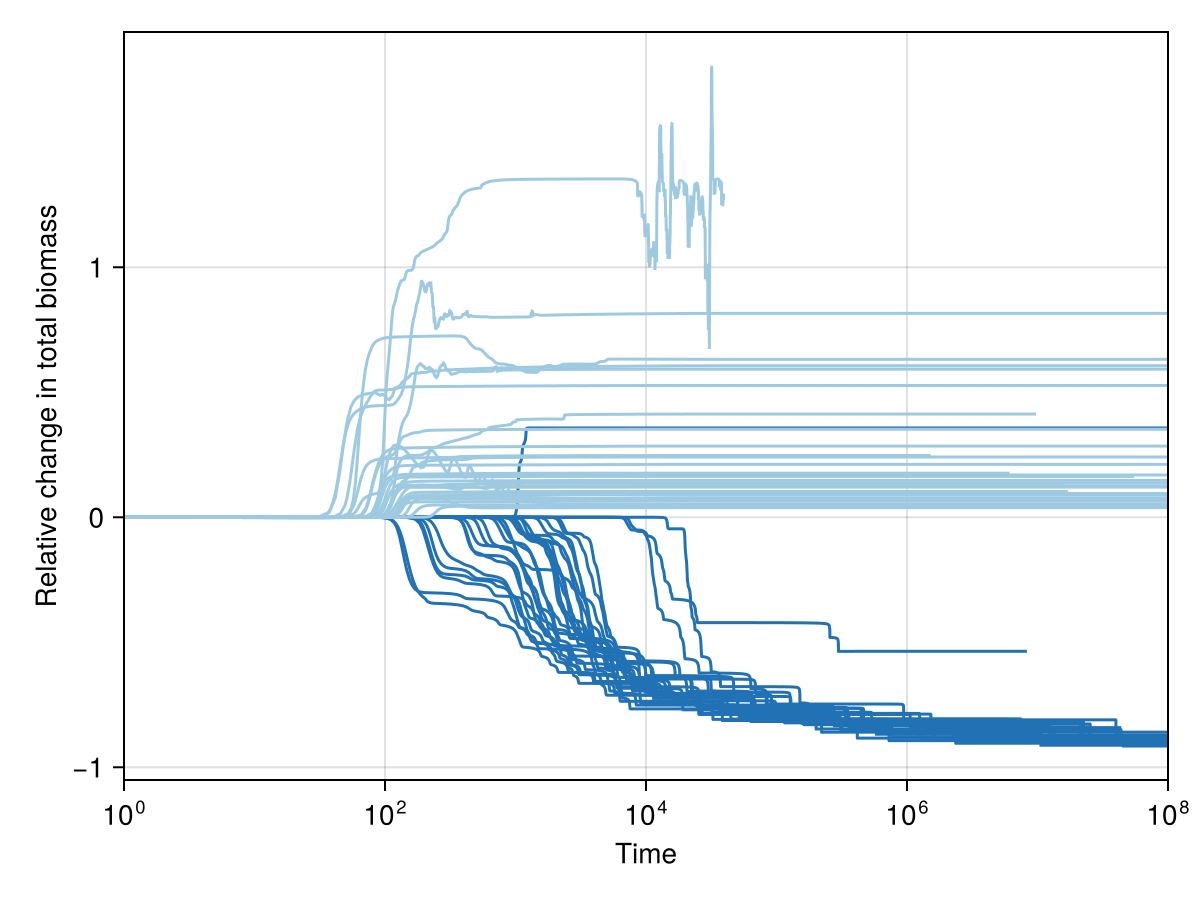

In [31]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel="Time",
    ylabel="Relative change in total biomass",
)

pcols = ColorSchemes.Blues[[end-2,4]]
for (p, pcol) in zip(smd.ps, pcols)
    for i in findall(==(p), df1.p)
        r = df1[i,:]
        ts = r.saved_ts
        totb = r.biomass_t
        
        ode_r = odes_df[r.df_row,:]
        hss_totbiom = sum(ode_r.final_states[1:Ns])
        
        lines!(ax, ts, (totb .- hss_totbiom) ./ hss_totbiom;
            color=pcol
        )
    end
end

xlims!(ax, 1., 1e8)

fig

# Looking at one row

In [55]:
for i in 1:nrow(df)
    r = df[i,:]
    if ((r.biomass_t[end] - r.biomass_t[1]) > 0.) && (r.p == 1.)
        @show i r
    end
end

i = 37
r = DataFrameRow
 Row │ run     pde_df_row  gdf_row  df_row  p        L        sN     T        retcode  final_state                        final_T  maxresid     num_saved  realtime  saved_ts                           biomass_t
     │ String  Int64       Int64    Int64   Float64  Float64  Int64  Float64  T        Array…                             Float64  Float64      Int64      Float64   Array…                             Array…
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  37 │ data            37       19     104      1.0  34.1925   1000    1.0e8  Success  [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.…    1.0e8  3.79848e-13         97   1042.11  [0.0, 5.23398e-13, 2.41762e-5, 0…  [5.80007, 5.80007, 5.80007, 5.80…
i = 97
r = DataFrameRow
 Row │ run     pde_df_row  gdf_row  df_row  p        L        sN  

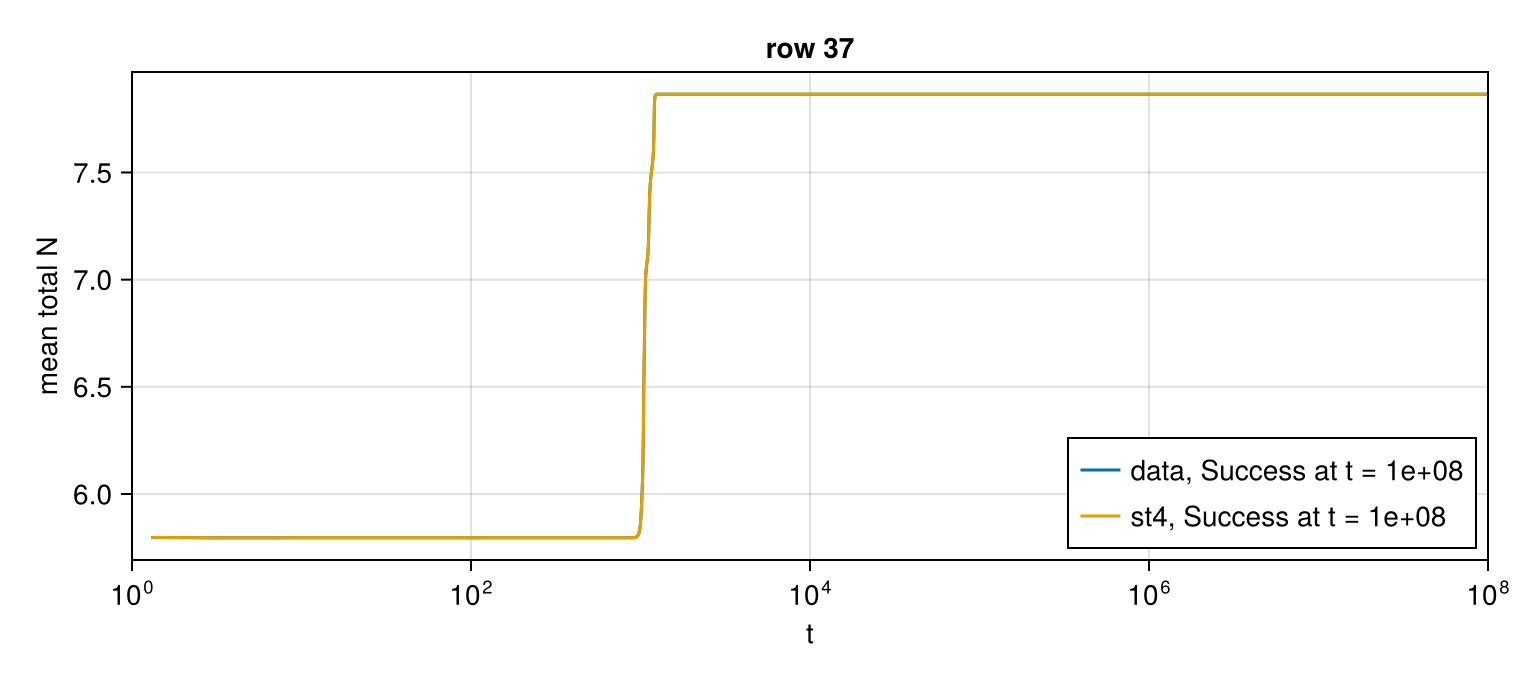

In [56]:
pde_row = 37                # any pde_df_row
trange = (1e0, T)        # the solver saves a few states at t ~ 1e-17

fig = Figure(; size=(760, 340))
ax = Axis(fig[1, 1]; xscale=log10, xlabel="t", ylabel="mean total N",
    title=@sprintf("row %d", pde_row))

for g in groupby(df[df.pde_df_row.==pde_row, :], :run)
    r = only(eachrow(g))
    keep = findall(t -> trange[1] <= t <= trange[2], r.saved_ts)
    lines!(ax, r.saved_ts[keep], r.biomass_t[keep];
        label=@sprintf("%s, %s at t = %.3g", r.run, string(r.retcode), r.final_T))
end
xlims!(ax, trange)
axislegend(ax; position=:rb)

fig

# Interactive view

The spatial state at a chosen save, with the save index on a slider. GLMakie, opens in its own window.

`pde_row` and `which` are plain variables rather than sliders: changing either reads a different row file off disk, so the figure has to be rebuilt. Rerun the cell after changing them.

Only the rows whose full `saved_us` were kept locally can be shown - `run_stats.jld2` has everything except the states. The cell lists what is available if the one asked for is not there.

In [59]:
pde_row = 37            # any pde_df_row whose row file is here, see the error below if it is not
which = :data           # :data or :st4
share_threshold = 0.01  # only strains/resources holding this share of the total get a legend entry

dirs = (; data="data", st4="data_st4_all")

# run_stats.jld2 dropped the states, so only the rows whose row file was kept can be shown
dir = dirs[which]
fname = joinpath(dir, @sprintf("row%04d.jld2", pde_row))
if !isfile(fname)
    avail = Dict(k => sort(parse.(Int, [m.captures[1] for f in readdir(d)
                                        for m in [match(r"^row(\d+)\.jld2$", f)] if m !== nothing]))
                 for (k, d) in pairs(dirs))
    error(@sprintf("no states for row %d in %s (%s); locally available: %s",
        pde_row, string(which), dir, string(avail)))
end

GLMakie.activate!()

sr = setup_df[pde_row, :]
ns, nr = get_Ns(sr.params)
xs = ((1:sr.sN) .- 0.5) ./ sr.sN  # x / L, same convention as Row28

(; ts, us) = load_pde_states(dir, pde_row)

ymaxN = maximum(maximum(sum(view(u, 1:ns, :); dims=1)) for u in us)  # the total, which is above every single strain
ymaxR = maximum(maximum(view(u, (ns+1):(ns+nr), :)) for u in us)

# every strain and resource is drawn. Only the ones carrying a share of the total
# get a legend entry - 20 a panel is unreadable - and the shares are summed over
# the whole series, so a colour and a label mean the same at every slider position.
tot_s = [sum(sum(view(u, s, :)) for u in us) for s in 1:ns]
tot_r = [sum(sum(view(u, ns + a, :)) for u in us) for a in 1:nr]
share_s = tot_s ./ sum(tot_s)
share_r = tot_r ./ sum(tot_r)
bigN = findall(>=(share_threshold), share_s)
bigR = findall(>=(share_threshold), share_r)

ncols = Makie.resample_cmap(ColorSchemes.tab20, max(ns, 2))
rcols = Makie.resample_cmap(ColorSchemes.tab20b, max(nr, 2))

hss_tot = sum(load("test1.jld2", "df")[sr.df_row, :final_states][1:ns])  # well-mixed total, for scale

fig = Figure(; size=(1000, 700))
sl = Slider(fig[3, 1], range=eachindex(ts), startvalue=length(ts))
u_at = lift(i -> us[i], sl.value)

axN = Axis(fig[1, 1]; ylabel="N",
    title=lift(i -> @sprintf("row %d, %s, p = %.3g, L = %.4g - save %d of %d, t = %.6g",
        pde_row, string(which), sr.p, sr.L, i, length(ts), ts[i]), sl.value))
pN = [lines!(axN, xs, lift(u -> u[s, :], u_at); color=ncols[s], linewidth=1) for s in 1:ns]
ptot = lines!(axN, xs, lift(u -> vec(sum(view(u, 1:ns, :), dims=1)), u_at);
    color=:black, linestyle=:dash, linewidth=1)
hlines!(axN, hss_tot; color=:black, linewidth=0.6)  # the well-mixed total
ylims!(axN, -0.02ymaxN, 1.05ymaxN)
axislegend(axN, vcat(pN[bigN], [ptot]),
    vcat([@sprintf("N%d (%.1f%%)", s, 100share_s[s]) for s in bigN], ["total"]);
    position=:rt, nbanks=2, framevisible=true)

axR = Axis(fig[2, 1]; xlabel="x / L", ylabel="R")
pR = [lines!(axR, xs, lift(u -> u[ns+a, :], u_at); color=rcols[a], linewidth=1) for a in 1:nr]
ylims!(axR, -0.02ymaxR, 1.05ymaxR)
axislegend(axR, pR[bigR], [@sprintf("R%d (%.1f%%)", a, 100share_r[a]) for a in bigR];
    position=:rt, nbanks=2, framevisible=true)

# left/right arrows step one save; hold to repeat. Needs the GLMakie window focused.
on(events(fig).keyboardbutton) do e
    if e.action in (Keyboard.press, Keyboard.repeat)
        i, rr = sl.value[], sl.range[]
        e.key == Keyboard.left && set_close_to!(sl, max(first(rr), i - 1))
        e.key == Keyboard.right && set_close_to!(sl, min(last(rr), i + 1))
    end
    Consume(false)
end

linkxaxes!(axN, axR)
hidexdecorations!(axN; grid=false)
Label(fig[4, 1], "drag the slider or use left/right arrows; ylims are fixed to the whole series so frames are comparable";
    color=:grey50, tellwidth=false)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)